In [ ]:
'''
Note on the 30 m → 5 km spatial aggregation:
The 30 m raster is aggregated to the UKCP 5 km grid using a centre-based pixel assignment. The centre coordinates of the UKCP 5 km cells (projection_x_coordinate and projection_y_coordinate) were verified against the corresponding coordinate bounds (projection_x_coordinate_bnds and projection_y_coordinate_bnds). For example, the x coordinate −197,500 m has bounds −200,000 to −195,000 m, confirming that −197,500 m represents the centre of the 5 km cell. During aggregation, each 30 m pixel is assigned to the 5 km cell containing its centre. Mean values are then calculated from the assigned 30 m pixels for continuous variables, while the modal class is calculated for categorical variables. This centre-based approach avoids the need for area-weighting where 5 km cell boundaries do not coincide exactly with the 30 m grid.
'''

In [1]:
import os
import rioxarray as rxr
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import re
from tqdm import tqdm
from rioxarray.merge import merge_arrays
import math

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"

from functions import aggregate_to_5km, convert_to_netcdf

### Get hydraulic conductivity lookup

In [2]:
soils_lookup = pd.read_csv("../../Data/Rawls_soil_lookup.csv")

# 1. Build a lookup dictionary from the CSV
#    adjust column name to match your actual hydraulic conductivity column
hc_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Hydraulic_conductivity"]))

ep_lookup = dict(zip(
    soils_lookup["USDA_soil"],
    soils_lookup["Effective_porosity"]))

### Get catchment data

In [3]:
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")
ha_nums = catchments['HA_NUM']

### Find soil texture, hydraulic conductiity, effective porosity, depth and fumax at 30m over GB

In [4]:
hk_rasters_30m = []
ep_rasters_30m = []
texture_rasters_30m = [] 
lu_rasters_30m = [] 
fumax_rasters_30m = []

for ha_num in tqdm(ha_nums): 
    soil_file = SOIL_DIR + f"soil_30m_{ha_num}.tif" 
    if not os.path.exists(soil_file): 
        continue 
   
    # Get soil texture data 
    soil_texture = rxr.open_rasterio(soil_file).squeeze() 
    # avoid dask chunks here; merge wants computed arrays 
    soil_texture = soil_texture.where(soil_texture != -9999) 
    soil_values = soil_texture.values 
    
    #####################
    # Convert to HC values at 30cm
    #####################
    hk_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, hk in hc_lookup.items(): 
        hk_values[soil_values == usda_class] = hk 
        
    hk_raster = soil_texture.copy(data=hk_values) 
    hk_raster.name = "hydraulic_conductivity" 
    hk_raster.rio.write_crs(soil_texture.rio.crs, inplace=True) 
    hk_raster.attrs["units"] = "cm hr-1"
    hk_raster.attrs["source"] = "Rawls et al. (1983) lookup by USDA soil texture class"
    
    #####################
    # Convert to EP values at 30cm
    #####################
    ep_values = np.full(soil_values.shape, np.nan, dtype=np.float32) 
    
    for usda_class, ep in ep_lookup.items(): 
        ep_values[soil_values == usda_class] = ep 
        
    ep_raster = soil_texture.copy(data=ep_values) 
    ep_raster.name = "effective_porosity" 
    ep_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)     
    ep_raster.attrs["units"] = "cm3 cm-3"
      
    #####################
    # Convert to effective depth (lu) values at 30cm
    #####################
    hk_values = hk_raster.values  # cm hr-1

    # Lu = 4*sqrt(Ks) is defined for Ks in in/hr, Lu in inches.
    # Converting units through (1 in = 2.54 cm, 1 m = 100 cm) collapses to:
    #   Lu[m] = 0.06375 * sqrt(Ks[cm/hr])
    lu_values = 0.06375 * np.sqrt(hk_values)

    lu_raster = soil_texture.copy(data=lu_values)
    lu_raster.name = "effective_depth"
    lu_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    lu_raster.attrs["units"] = "m"
    
    #####################
    # Convert to effective depth (lu) values at 30cm
    # Mirrors LISFLOOD-FP Initialize_GrnAmpt_Soiltype() exactly, step for step.
    #####################
    hk_values = hk_raster.values  # Rawls et al. (1983) Ks, cm/hr

    # Step 1: cm/hr -> mm/hr
    # (matches Get_Soil_Type(), where Rawls cm/hr values are hardcoded already *10 as mm/hr)
    ks_mm_hr = hk_values * 10.0

    # Step 2: mm/hr -> m/s
    # (matches: Infilptr->Ks[index] = C(...) / (1000 * 3600);)
    ks_m_s = ks_mm_hr / (1000.0 * 3600.0)

    # Step 3: Lu = 4*sqrt(25.4*3.6)*sqrt(Ks[m/s])
    # [empirical constant] × [unit-conversion factor] × [√Ks, per pixel]
    # (matches: Infilptr->Lu[index] = 4 * sqrt(25.4 * 3.6) * sqrt(Infilptr->Ks[index]);)
    lu_values = 4.0 * math.sqrt(25.4 * 3.6) * np.sqrt(ks_m_s)

    lu_raster = soil_texture.copy(data=lu_values)
    lu_raster.name = "effective_depth"
    lu_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    lu_raster.attrs["units"] = "m"
    lu_raster.attrs["source"] = "LISFLOOD-FP Initialize_GrnAmpt_Soiltype(), Lu = 4*sqrt(25.4*3.6)*sqrt(Ks[m/s])"
    
    #####################
    # Convert to potential capacity (Fumax = IMDmax * Lu) at 30cm
    #####################
    fumax_values = ep_raster.values * lu_raster.values

    fumax_raster = soil_texture.copy(data=fumax_values)
    fumax_raster.name = "potential_capacity"
    fumax_raster.rio.write_crs(soil_texture.rio.crs, inplace=True)
    fumax_raster.attrs["units"] = "m"
    fumax_raster.attrs["source"] = "IMDmax * Lu, texture only (LISFLOOD-FP Fumax)"
        
    #####################
    # Append to lists
    #####################
    hk_rasters_30m.append(hk_raster)  
    ep_rasters_30m.append(ep_raster) 
    texture_rasters_30m.append(soil_texture)     
    lu_rasters_30m.append(lu_raster)
    fumax_rasters_30m.append(fumax_raster)

print("Merging arrays")
national_fumax_30m = merge_arrays(fumax_rasters_30m, nodata=np.nan)
national_fumax_30m.name = "potential_capacity"   

national_hc_30m = merge_arrays(hk_rasters_30m, nodata=np.nan) 
national_hc_30m.name = "hydraulic_conductivity" 

national_ep_30m = merge_arrays(ep_rasters_30m, nodata=np.nan) 
national_ep_30m.name = "effective_porosity" 

national_texture_30m = merge_arrays(texture_rasters_30m, nodata=np.nan) 
national_texture_30m.name = "soil_texture" 

national_lu_30m = merge_arrays(lu_rasters_30m, nodata=np.nan) 
national_lu_30m.name = "effective depth" 

100%|██████████████████████████████████████████████████████| 114/114 [01:12<00:00,  1.57it/s]


Merging arrays


In [29]:
pixel_area = 30 * 30  # m²
national_fumax_30m_volume = national_fumax_30m * pixel_area   # now in m³ per pixel
# fumax_volume_5km = fumax_volume_30m_within_cell.sum()  # m³ total

In [ ]:
national_fumax_30m_volume.to_netcdf("../../Data/SoilStaticVariables/Volume_FUmax_GB_30m.nc")

In [8]:
national_hc_30m.to_netcdf("../../Data/SoilStaticVariables/Mean_HydraulicConductivity_GB_30m.nc")
national_ep_30m.to_netcdf("../../Data/SoilStaticVariables/Mean_EffectivePorosity_GB_30m.nc")
national_lu_30m.to_netcdf("../../Data/SoilStaticVariables/Mean_EffectiveDepth_GB_30m.nc")
national_fumax_30m.to_netcdf("../../Data/SoilStaticVariables/Mean_FUmax_GB_30m.nc")
national_fumax_30m_volume.to_netcdf("../../Data/SoilStaticVariables/Volume_FUmax_GB_30m.nc")
national_texture_30m.to_netcdf("../../Data/SoilStaticVariables/Mode_SoilTexture_GB_30m.nc")

### Aggregate to 5km

In [17]:
# Continuous
hk_5km = aggregate_to_5km(national_hc_30m, agg_type="mean")
ep_5km = aggregate_to_5km(national_ep_30m,agg_type="mean")
lu_5km = aggregate_to_5km(national_lu_30m,agg_type="mean")
fumax_5km = aggregate_to_5km(national_fumax_30m,agg_type="mean")

# # Categorical
texture_5km = aggregate_to_5km(national_texture_30m, agg_type="mode")

Processing raster: 100%|█████████████████████████████████████| 71/71 [01:26<00:00,  1.21s/it]


In [18]:
hk_5km['aggregated_mean'].to_netcdf("../../Data/SoilStaticVariables/Mean_HydraulicConductivity_GB_5km.nc")
ep_5km['aggregated_mean'].to_netcdf("../../Data/SoilStaticVariables/Mean_EffectivePorosity_GB_5km.nc")
lu_5km['aggregated_mean'].to_netcdf("../../Data/SoilStaticVariables/Mean_EffectiveDepth_GB_5km.nc")
fumax_5km['aggregated_mean'].to_netcdf("../../Data/SoilStaticVariables/Mean_FUmax_GB_5km.nc")

texture_5km['mode'].to_netcdf("../../Data/SoilStaticVariables/Mode_SoilTexture_GB_5km.nc")
texture_5km['mode_proportion'].to_netcdf("../../Data/SoilStaticVariables/ModeProp_SoilTexture_GB_5km.nc")

### Check plotting

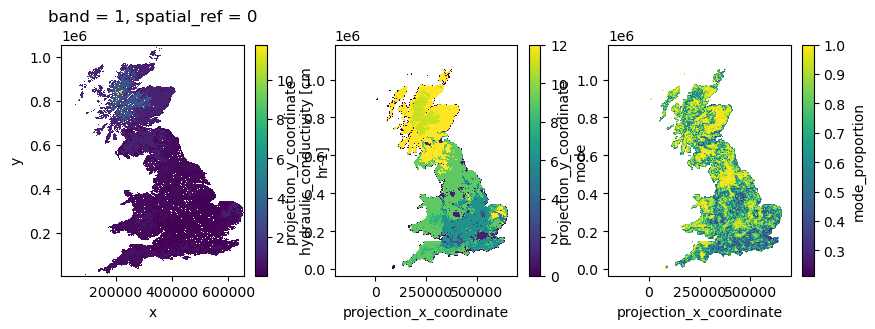

In [14]:
# hk_5km["aggregated_mean"].plot()
# ep_5km["aggregated_mean"].plot()

fig,axs=plt.subplots(ncols=3, figsize=(10,3))
plot_texture = national_hc_30m.isel( y=slice(None, None, 20),x=slice(None, None, 20))
plot_texture.plot(cmap="viridis", ax=axs[0], add_colorbar=True)
texture_5km["mode"].plot(ax=axs[1])
texture_5km["mode_proportion"].plot(ax=axs[2]);

In [20]:
np.nanmin(national_fumax_30m.data), np.nanmax(national_fumax_30m.data)


(np.float32(0.0042510694), np.float32(0.091240056))

In [25]:
np.nanmin(lu_5km['aggregated_mean']), np.nanmax(lu_5km['aggregated_mean'].data)
(np.float64(0.011041739024221897), np.float64(0.16692353618504283))

(np.float64(0.011041739024221897), np.float64(0.16692353618504283))

In [24]:
np.nanmin(lu_5km['aggregated_mean']), np.nanmax(lu_5km['aggregated_mean'].data)
(np.float64(0.011041739024221897), np.float64(0.16692353618504283))
np.nanmin(fumax_5km['aggregated_mean']), np.nanmax(fumax_5km['aggregated_mean'].data)
(np.float64(0.004251069389283657), np.float64(0.06876434045578961))

(np.float64(0.004251069389283657), np.float64(0.06876434045578961))

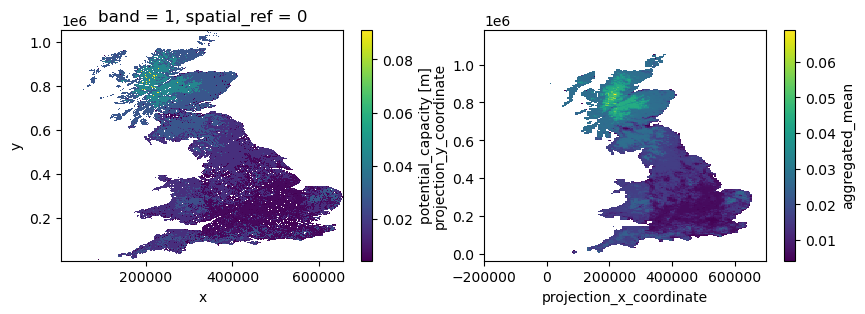

In [21]:
fig,axs=plt.subplots(ncols=2, figsize=(10,3))
plot_ep= national_fumax_30m.isel( y=slice(None, None, 20),x=slice(None, None, 20))
plot_ep.plot(cmap="viridis", ax=axs[0], add_colorbar=True)
fumax_5km["aggregated_mean"].plot(ax=axs[1]);